# AIML Module Project - Supervised Learning - Aaditya Kumar Ravi

## Part A

***• DOMAIN:*** Medical  
***• CONTEXT:*** Medical research university X is undergoing a deep research on patients with certain conditions. University has an internal AI team.   
Due to confidentiality the patient’s details and the conditions are masked by the client by providing different datasets to the AI team for 
developing a AIML model which can predict the condition of the patient depending on the received test results.  
***• DATA DESCRIPTION:*** The data consists of biomechanics features of the patients according to their current conditions. Each patient is 
represented in the data set by six biomechanics attributes derived from the shape and orientation of the condition to their body part.   
***• PROJECT OBJECTIVE:*** To Demonstrate the ability to fetch, process and leverage data to generate useful predictions by training Supervised 
Learning algorithms.  
***• STEPS AND TASK [30 Marks]:***

In [1]:
#Load some basic libraries required for computation, data loading and EDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

##### 1. Data Understanding: [5 Marks]
##### A. Read all the 3 CSV files as DataFrame and store them into 3 separate variables. [1 Mark]

In [2]:
# we will load 3 csv files given to use for part 1 in insturctions: Normal.csv, Type_H.csv, Type_S.csv
nData = pd.read_csv('Normal.csv')
hData = pd.read_csv('Type_H.csv')
sData = pd.read_csv('Type_S.csv')

In [3]:
#Read the data to verify it is loaded successfully
nData.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,38.505273,16.964297,35.112814,21.540976,127.632875,7.986683,Normal
1,54.920858,18.968430,51.601455,35.952428,125.846646,2.001642,Normal
2,44.362490,8.945435,46.902096,35.417055,129.220682,4.994195,Normal
3,48.318931,17.452121,48.000000,30.866809,128.980308,-0.910941,Normal
4,45.701789,10.659859,42.577846,35.041929,130.178314,-3.388910,Normal


In [4]:
#Read the data to verify it is loaded successfully
hData.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Type_H
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Type_H
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Type_H
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Type_H
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Type_H


In [5]:
#Read the data to verify it is loaded successfully
sData.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,74.377678,32.053104,78.772013,42.324573,143.560690,56.125906,Type_S
1,89.680567,32.704435,83.130732,56.976132,129.955476,92.027277,Type_S
2,44.529051,9.433234,52.000000,35.095817,134.711772,29.106575,Type_S
3,77.690577,21.380645,64.429442,56.309932,114.818751,26.931841,Type_S
4,76.147212,21.936186,82.961502,54.211027,123.932010,10.431972,Type_S


##### B. Print Shape and columns of all the 3 DataFrames. [1 Mark]

In [6]:
# shape and columns of nData dataframe
print("Shape of nData dataframe:",nData.shape)
print("Columns in nData dataframe:",nData.columns)

Shape of nData dataframe: (100, 7)
Columns in nData dataframe: Index(['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree',
       'Class'],
      dtype='object')


In [7]:
# shape and columns of hData dataframe
print("Shape of hData dataframe:",hData.shape)
print("Columns in hData dataframe:",hData.columns)

Shape of hData dataframe: (60, 7)
Columns in hData dataframe: Index(['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree',
       'Class'],
      dtype='object')


In [8]:
# shape and columns of sData dataframe
print("Shape of sData dataframe:",sData.shape)
print("Columns in sData dataframe:",sData.columns)

Shape of sData dataframe: (150, 7)
Columns in sData dataframe: Index(['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree',
       'Class'],
      dtype='object')


#### Observations:
* nData has 100 rows and 7 columns
* hData has 60 rows and 7 columns
* sData has 150 rows and 7 columns

##### C. Compare Column names of all the 3 DataFrames and clearly write observations. [1 Mark]

In [9]:
# we should check names, order and datatype of all the columns in each dataframe
if (list(nData.columns)==list(hData.columns)==list(sData.columns) and #checks the name and order
    list(nData.dtypes)==list(hData.dtypes)==list(sData.dtypes)):      #checks the datatype
    print("All DataFrames nData, hData and sData have the same column names, order, and data types.")
else:
    print("Not all DataFrames  nData, hData and sData have the same column names, order, and data types.")

All DataFrames nData, hData and sData have the same column names, order, and data types.


#### Observation:
* Yes, the above data frames nData, hData, sData has the same column name, order and datatypes

##### D. Print DataTypes of all the 3 DataFrames. [1 Mark]

In [10]:
nData.dtypes

P_incidence    float64
P_tilt         float64
L_angle        float64
S_slope        float64
P_radius       float64
S_Degree       float64
Class           object
dtype: object

In [11]:
hData.dtypes

P_incidence    float64
P_tilt         float64
L_angle        float64
S_slope        float64
P_radius       float64
S_Degree       float64
Class           object
dtype: object

In [12]:
sData.dtypes

P_incidence    float64
P_tilt         float64
L_angle        float64
S_slope        float64
P_radius       float64
S_Degree       float64
Class           object
dtype: object

In [13]:
nData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   P_incidence  100 non-null    float64
 1   P_tilt       100 non-null    float64
 2   L_angle      100 non-null    float64
 3   S_slope      100 non-null    float64
 4   P_radius     100 non-null    float64
 5   S_Degree     100 non-null    float64
 6   Class        100 non-null    object 
dtypes: float64(6), object(1)
memory usage: 5.6+ KB


In [14]:
hData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   P_incidence  60 non-null     float64
 1   P_tilt       60 non-null     float64
 2   L_angle      60 non-null     float64
 3   S_slope      60 non-null     float64
 4   P_radius     60 non-null     float64
 5   S_Degree     60 non-null     float64
 6   Class        60 non-null     object 
dtypes: float64(6), object(1)
memory usage: 3.4+ KB


In [15]:
sData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   P_incidence  150 non-null    float64
 1   P_tilt       150 non-null    float64
 2   L_angle      150 non-null    float64
 3   S_slope      150 non-null    float64
 4   P_radius     150 non-null    float64
 5   S_Degree     150 non-null    float64
 6   Class        150 non-null    object 
dtypes: float64(6), object(1)
memory usage: 8.3+ KB


#### Observation:
* 6 columns(P_incidence, P_tilt, L_angle, S_slope, P_radius, S_Degree) out of 7 in all the datasets are of float64 type and 7th column(Class) is of object type

##### E. Observe and share variation in ‘Class’ feature of all the 3 DaraFrames. [1 Mark]

In [16]:
nData['Class'].value_counts()

Normal    73
Nrmal     27
Name: Class, dtype: int64

#### Observation:
* nData has Normal class which is written in two way Normal and Nrmal, we can make it uniform/consistent as both represents Normal i.e same class only. Nrmal may be due to mistake in writing or a lack of defined rule for class while collecting data.

In [17]:
hData['Class'].value_counts()

Type_H    37
type_h    23
Name: Class, dtype: int64

#### Observation:
* hData has Type_H class which is written in two way Type_H and type_h, we can make it uniform/consistent as both represents Type_H i.e same class only. type_h may be due to mistake in writing or a lack of defined rule for class while collecting data.

In [18]:
sData['Class'].value_counts()

Type_S    133
tp_s       17
Name: Class, dtype: int64

#### Observation:
* sData has Type_S class which is written in two way Type_S and tp_s, we can make it uniform/consistent as both represents Type_S i.e same class only. tp_s may be due to mistake in writing or a lack of defined rule for class while collecting data.

#### So we have mainly 3 classes: Normal, Type_H, Type_S

##### 2. Data Preparation and Exploration: [5 Marks]

##### A. Unify all the variations in ‘Class’ feature for all the 3 DataFrames. [1 Marks]

In [19]:
# We will convert Nrml to Normal, type_h to Type_H, tp_s to Type_S to make it uniform
nData['Class']=nData['Class'].replace('Nrmal','Normal')
nData['Class'].value_counts()

Normal    100
Name: Class, dtype: int64

* After replacing the count of class having Normal is equal to the total rows in nData i.e 100. 

In [20]:
hData['Class']=hData['Class'].replace('type_h','Type_H')
hData['Class'].value_counts()

Type_H    60
Name: Class, dtype: int64

* After replacing the count of class having Type_H is equal to the total rows in hData i.e 60. 

In [21]:
sData['Class']=sData['Class'].replace('tp_s','Type_S')
sData['Class'].value_counts()

Type_S    150
Name: Class, dtype: int64

* After replacing the count of class having Type_S is equal to the total rows in sData i.e 150. 

##### B. Combine all the 3 DataFrames to form a single DataFrame [1 Marks]

In [22]:
combined = pd.concat([nData,hData,sData],ignore_index=True) #concatinating the 3 dataframes

In [23]:
combined #read the dataframe to verify if it has combined

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,38.505273,16.964297,35.112814,21.540976,127.632875,7.986683,Normal
1,54.920858,18.968430,51.601455,35.952428,125.846646,2.001642,Normal
2,44.362490,8.945435,46.902096,35.417055,129.220682,4.994195,Normal
3,48.318931,17.452121,48.000000,30.866809,128.980308,-0.910941,Normal
4,45.701789,10.659859,42.577846,35.041929,130.178314,-3.388910,Normal
...,...,...,...,...,...,...,...
305,80.111572,33.942432,85.101608,46.169139,125.593624,100.292107,Type_S
306,95.480229,46.550053,59.000000,48.930176,96.683903,77.283072,Type_S
307,74.094731,18.823727,76.032156,55.271004,128.405731,73.388216,Type_S
308,87.679087,20.365613,93.822416,67.313473,120.944829,76.730629,Type_S


In [24]:
combined['Class'].value_counts()

Type_S    150
Normal    100
Type_H     60
Name: Class, dtype: int64

In [25]:
combined.shape

(310, 7)

* We can see, when 3 dataframes are combined, it created 310 rows which is 100 for nData, 60 for hData, 150 for sData 

In [26]:
#We can save it to csv file using below code if needed
combined.to_csv('combined.csv',index=False)

##### C. Print 5 random samples of this DataFrame [1 Marks]

In [27]:
# We can use sample method on combined dataset to show random 
random_sample = combined.sample(5)
random_sample

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
282,75.437748,31.539454,89.600000,43.898294,106.829590,54.965789,Type_S
61,42.515610,16.541216,42.000000,25.974394,120.631941,7.876731,Normal
279,68.721910,49.431864,68.056012,19.290046,125.018517,54.691289,Type_S
117,31.276012,3.144669,32.562996,28.131342,129.011418,3.623020,Type_H
241,89.504947,48.903653,72.003423,40.601295,134.634291,118.353370,Type_S


* We can see it has loaded 5 random sample rows as its index can be noticed is random

##### D. Print Feature-wise percentage of Null values. [1 Mark]

In [28]:
(combined.isnull().sum()*100)/len(combined)

P_incidence    0.0
P_tilt         0.0
L_angle        0.0
S_slope        0.0
P_radius       0.0
S_Degree       0.0
Class          0.0
dtype: float64

* Each feature is having 0.0% null values, means none of the value is null in any column

##### E. Check 5-point summary of the new DataFrame. [1 Mark]

In [29]:
#if we just want to see 5 point summary we can select specific points to display
combined.describe().loc[['min', '25%', '50%', '75%', 'max']]

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


In [30]:
#if we want to show the entire descirbe, we can do as below:
combined.describe()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


##### 3. Data Analysis: [10 Marks]

##### A. Visualize a heatmap to understand correlation between all features [2 Marks]

In [31]:
# correlation between numerical columns
combined_corr = combined[['P_incidence','P_tilt','L_angle','S_slope','P_radius','S_Degree']].corr()
combined_corr

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree
P_incidence,1.000000,0.629199,0.717282,0.814960,-0.247467,0.638743
P_tilt,0.629199,1.000000,0.432764,0.062345,0.032668,0.397862
L_angle,0.717282,0.432764,1.000000,0.598387,-0.080344,0.533667
S_slope,0.814960,0.062345,0.598387,1.000000,-0.342128,0.523557
P_radius,-0.247467,0.032668,-0.080344,-0.342128,1.000000,-0.026065
S_Degree,0.638743,0.397862,0.533667,0.523557,-0.026065,1.000000


<Axes: >

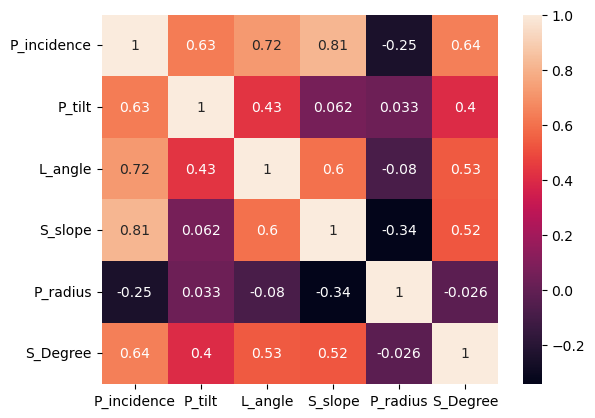

In [32]:
# plot a heatmap with above correlation
sns.heatmap(combined_corr, annot=True)

##### B. Share insights on correlation. [2 Marks]
##### A. Features having stronger correlation with correlation value.
##### B. Features having weaker correlation with correlation value

#### Observation:
* Strong positive correlation is between S_slope and P_incidence and the correlation value is 0.81
* P_incidence has positive correlation with all the other columns(P_tilt 0.63, L_angle 0.72, S_slope 0.81, S_Degree 0.64) except P_radius(-0.25) which has negative correlation with P_incidence
* S_Degree also has positive correlation with L_angle 0.53 and S_slope 0.52
* There is no very strong negative correlation between any columns, though negative correlation between P_radius and S_slope can be seen and the correlation value is -0.34
* Weekest Correlation in this plot can be seen between S_Degree and P_radius and the correlation value is -0.026
* Week correlation can also be seen between P_radius & P_tilt(correlation value: 0.033), S_slope & P_tilt(correlation value: 0.062), P_radius & L_angle(correlation value: -0.08)

##### C. Visualize a pairplot with 3 classes distinguished by colors and share insights. [2 Marks]

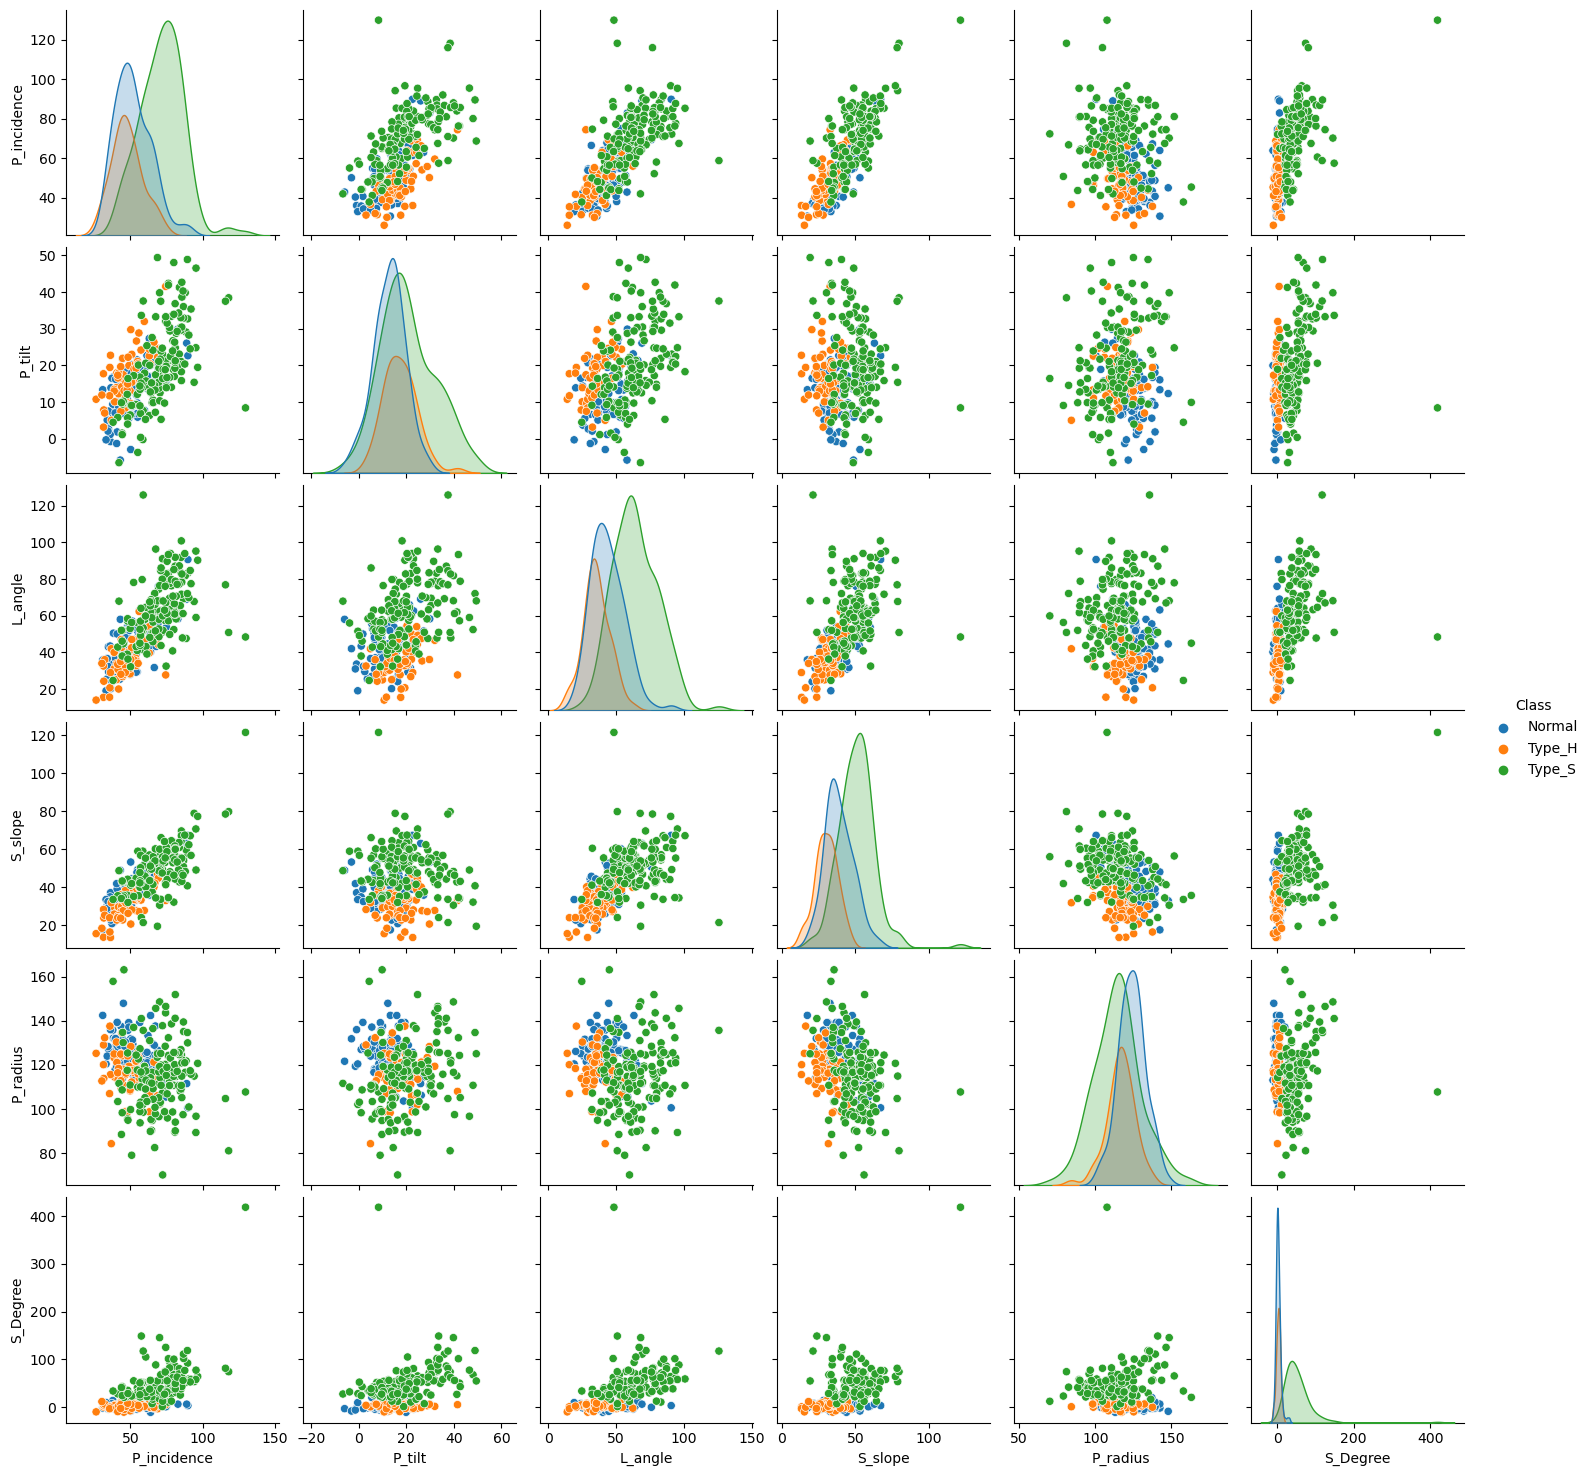

In [33]:
sns.pairplot(combined, hue='Class')

#### Insights:
* Type_S has highest density followed by Normal and then Type_H
* P_incidence and S_slope has strong positive correlation
* P_incidence has positive correlation with features P_tilt, L_angle, S_slope, S_Degree
* P_incidence has negative correlation with P_radius
* L_angle and S_slope also has positive correlation
* P_radius has week or negative correlation with all the other columns
* S_Degree and P_radius has weekest correlation

##### D. Visualize a jointplot for ‘P_incidence’ and ‘S_slope’ and share insights. [2 Marks]

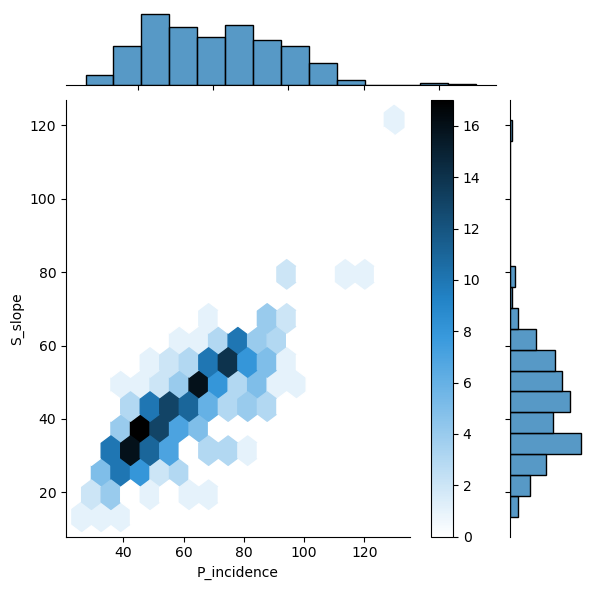

In [34]:
sns.jointplot(combined, x='P_incidence', y='S_slope', kind='hex')
plt.colorbar()

* We can see high distribution density of data point at P_incidence 40 to 50 and S_slope 30 to 40. Also at around P_incidence 50 and s_slope 65

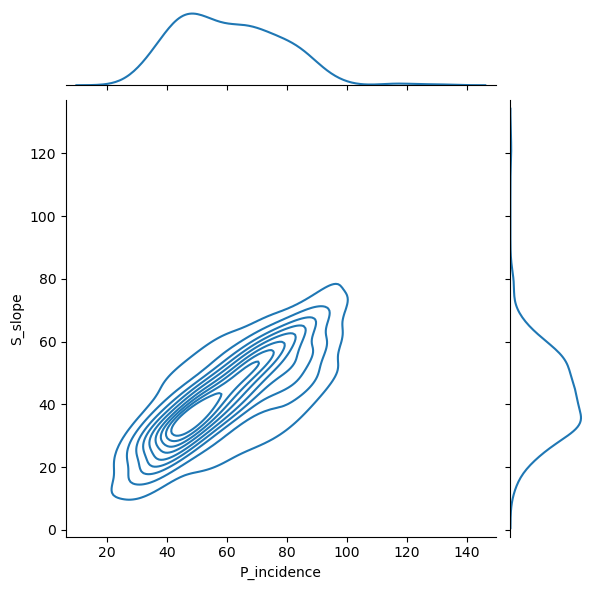

In [35]:
sns.jointplot(combined, x='P_incidence', y='S_slope', kind='kde')

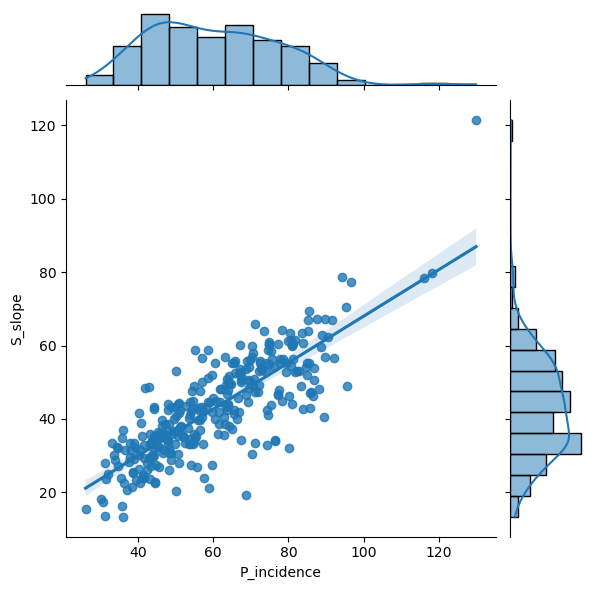

In [36]:
sns.jointplot(combined, x='P_incidence', y='S_slope', kind='reg')

#### Insights:
* We can see the strong positive correlation between P_incidence and S_slope feature
* There is one outlier where P_incidence & S_slope both has value > 120, Let us visualize that data below
* Highest distribution density of P_incidence between 40 & 50
* Highest distribution density of S_slope between 25 to 35

In [37]:
combined.loc[(combined['P_incidence']>120) & (combined['S_slope']>120)] # see the record having p_incidence > 120

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
215,129.834041,8.404475,48.384057,121.429566,107.690466,418.543082,Type_S


* Outlier is from Type_S class

##### E. Visualize a boxplot to check distribution of the features and share insights. [2 Marks]

<Axes: >

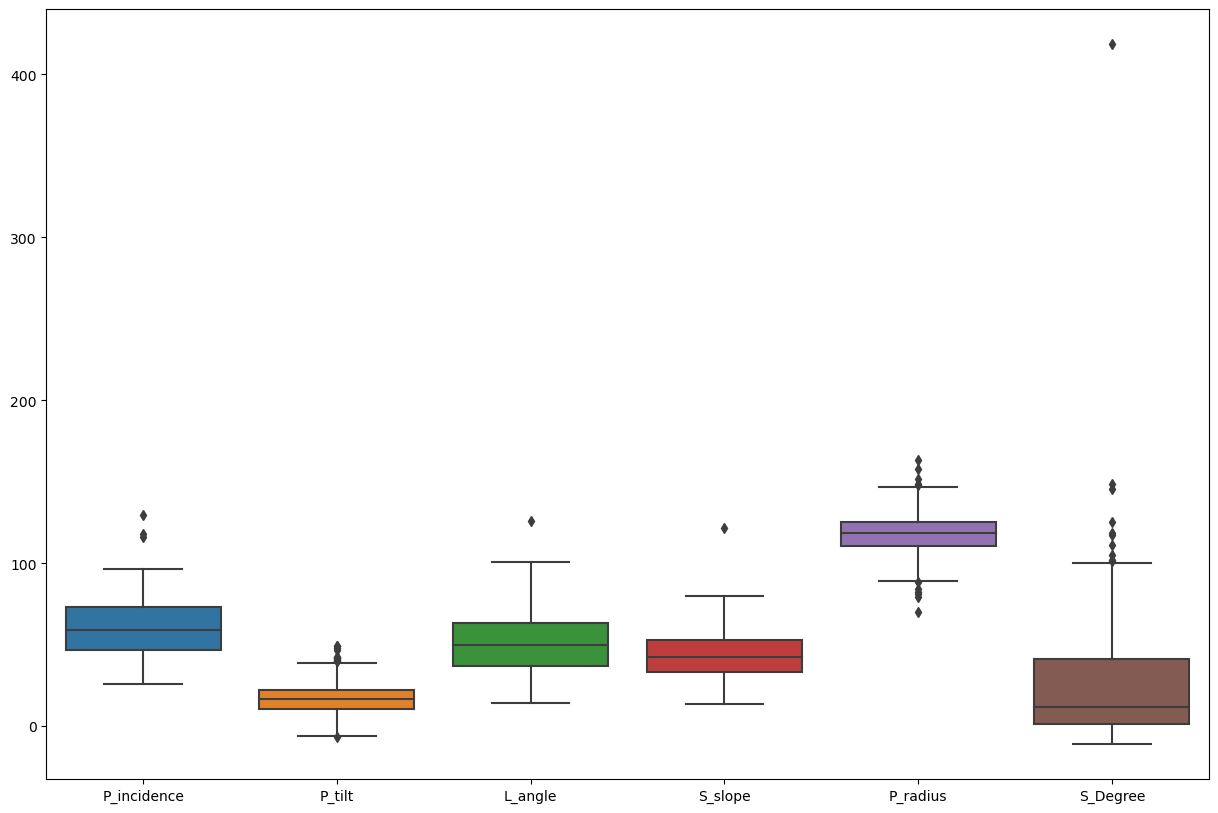

In [38]:
# Visualize the box plot for all features at once 
plt.figure(figsize = (15,10))
sns.boxplot(combined)

#### Insights:
* All the features have some outliers
* S_Degree has largest outlier value greater than 400
* P_tilt and P_radius has outliers from both side(lower and higher side)
* P_incidence has outlier value greater than 100

In [39]:
combined.describe()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


#### Let us take closer look on each box plot:

<Axes: xlabel='P_tilt'>

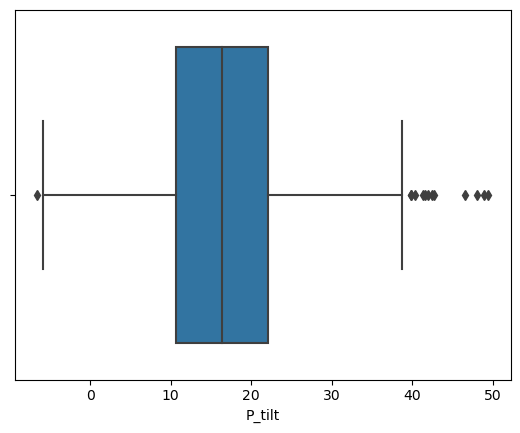

In [40]:
sns.boxplot(combined, x='P_tilt')

* Both side outlier
* P_tilt has outlier value somewhere around greater than 38
* P_tilt has lower side outlier value somewehre around less than -0.5

<Axes: xlabel='L_angle'>

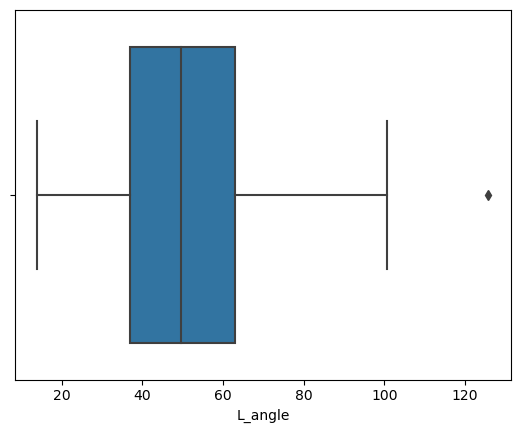

In [41]:
sns.boxplot(combined, x='L_angle')

* L_angle has outlier value greater than 120

<Axes: xlabel='S_slope'>

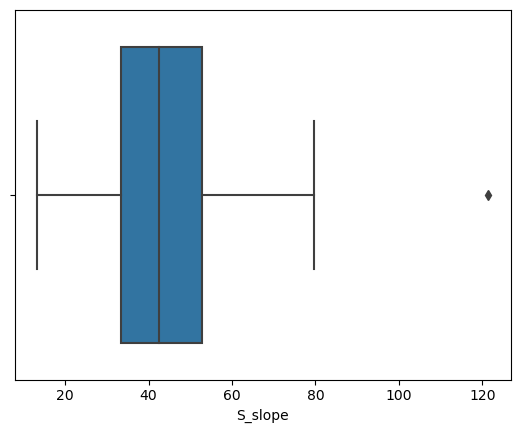

In [42]:
sns.boxplot(combined, x='S_slope')

* S_slope has outlier value greater than 120

<Axes: xlabel='P_radius'>

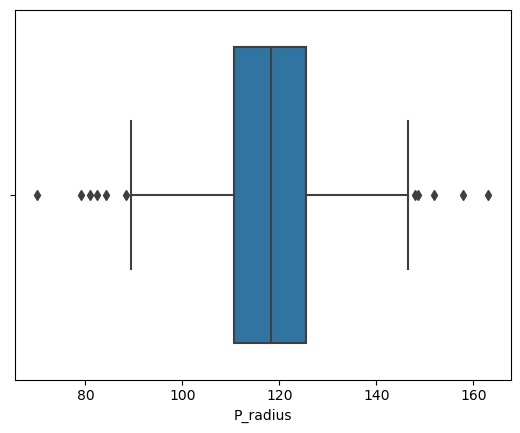

In [43]:
sns.boxplot(combined, x='P_radius')

* P_radius has lower side outlier value around less than 90 and higher side outlier value around greater than 143

<Axes: xlabel='S_Degree'>

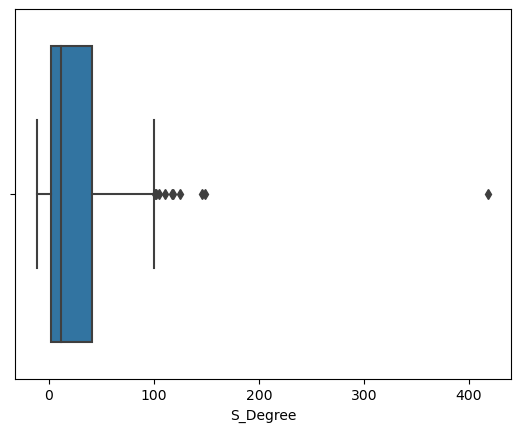

In [44]:
sns.boxplot(combined, x='S_Degree')

* S_Degree also has outlier greater than 100 and one outlier is far away which is greater than 400

##### 4. Model Building: [6 Marks]
##### A. Split data into X and Y. [1 Marks]

In [45]:
X=combined.drop('Class',axis=1) #takes all the columns except Class 
Y=combined['Class'] #takes only the column Class

In [46]:
#Read X to verify it is split correctly
X.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree
0,38.505273,16.964297,35.112814,21.540976,127.632875,7.986683
1,54.920858,18.968430,51.601455,35.952428,125.846646,2.001642
2,44.362490,8.945435,46.902096,35.417055,129.220682,4.994195
3,48.318931,17.452121,48.000000,30.866809,128.980308,-0.910941
4,45.701789,10.659859,42.577846,35.041929,130.178314,-3.388910


In [47]:
#Read Y to verify if it is split correctly
Y.head()

0    Normal
1    Normal
2    Normal
3    Normal
4    Normal
Name: Class, dtype: object

##### B. Split data into train and test with 80:20 proportion. [1 Marks]

In [48]:
from scipy.stats import zscore
# convert the features into z scores as we do not know what units/scales were used and It is always advisable to scale 
# numeric attributes in models that calculate distances.
XScaled  = X.apply(zscore)  # convert all attributes to Z scale 
XScaled

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree
0,-1.277922,-0.057898,-0.907904,-1.597803,0.730468,-0.488288
1,-0.324010,0.142672,-0.017786,-0.522437,0.596124,-0.647896
2,-0.937559,-0.860412,-0.271475,-0.562386,0.849889,-0.568091
3,-0.707649,-0.009077,-0.212206,-0.901920,0.831811,-0.725568
4,-0.859732,-0.688835,-0.504914,-0.590377,0.921914,-0.791650
...,...,...,...,...,...,...
305,1.139826,1.641245,1.790676,0.239923,0.577094,1.973295
306,2.032901,2.902995,0.381614,0.445948,-1.597243,1.359695
307,0.790186,0.128191,1.301073,0.919094,0.788596,1.255828
308,1.579575,0.282500,2.261457,1.817689,0.227452,1.344962


In [49]:
from sklearn.model_selection import train_test_split 
#split the data into 80:20 proportion for training and testing respectively 
X_train, X_test, Y_train, Y_test = train_test_split(XScaled, Y, test_size=0.2, random_state=1) 

In [50]:
#Let us verify the data size of X_train, Y_train, X_test, Y_test if it is split in 80:20 ratio
print("X_train size(in percentage):",X_train.shape[0]*100/XScaled.shape[0])
print("Y_train size(in percentage):",Y_train.shape[0]*100/Y.shape[0])

print("X_test size(in percentage):",X_test.shape[0]*100/XScaled.shape[0])
print("Y_test size(in percentage):",Y_test.shape[0]*100/Y.shape[0])

X_train size(in percentage): 80.0
Y_train size(in percentage): 80.0
X_test size(in percentage): 20.0
Y_test size(in percentage): 20.0


##### C. Train a Supervised Learning Classification base model using KNN classifier. [2 Marks]

In [51]:
from sklearn.neighbors import KNeighborsClassifier
kNNModel = KNeighborsClassifier(n_neighbors=5, weights='distance') #instantiate the KNN Classifier model

In [52]:
kNNModel.fit(X_train, Y_train) #train the model

KNeighborsClassifier(weights='distance')

##### D. Print all the possible performance metrics for both train and test data. [2 Marks]

In [53]:
# check the performance on training data i.e training score
kNNModel.score(X_train, Y_train)

1.0

* 100% score on training data which is very good. we will see the score on test data

In [54]:
# Predict the Class on X_test data
predicted_class = kNNModel.predict(X_test)
# check the performance on test data i.e test score
kNNModel.score(X_test, Y_test)

0.7258064516129032

* just 72.5% score on test data, which is not very good. it is having average performance on test data compared to the training data. it is looking like an overfit. 

#### Let us check the confusion matrix

In [55]:
lab = list(combined['Class'].unique())  # list the available class to show actual value label
lab

['Normal', 'Type_H', 'Type_S']

In [56]:
plab=["Pr "+s for s in lab] # prepend the Pr keyword to denote predicted value label
plab

['Pr Normal', 'Pr Type_H', 'Pr Type_S']

<Axes: >

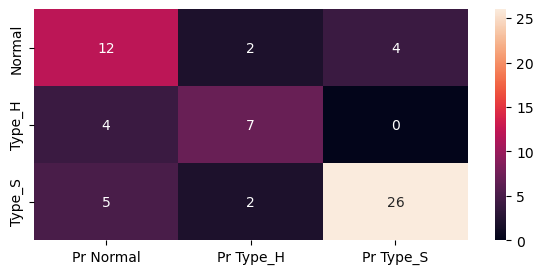

In [70]:
from sklearn import metrics
# draw confustion matrix and plot that through heatmap
cm = metrics.confusion_matrix(Y_test, predicted_class, labels=lab)
cmdf = pd.DataFrame(cm, index=[l for l in lab], columns=[l for l in plab])
plt.figure(figsize=(7,3))
sns.heatmap(cmdf, annot=True) 

In [71]:
#print all the performance matrics
print(metrics.classification_report(Y_test, predicted_class, labels=lab))

              precision    recall  f1-score   support

      Normal       0.57      0.67      0.62        18
      Type_H       0.64      0.64      0.64        11
      Type_S       0.87      0.79      0.83        33

    accuracy                           0.73        62
   macro avg       0.69      0.70      0.69        62
weighted avg       0.74      0.73      0.73        62



* Precision for Normal class is 0.57, which indicates that out of all classes predicted as Normal, 57% are true Normal.
* Precision for Type_H class is 0.64, which indicates that out of all classes predicted as Type_H, 64% are true Type_H.
* Precision for Type_S class is 0.87, which indicates that out of all classes predicted as Type_S, 87% are true Type_S.  
&emsp;  
* Recall for Normal class is 0.67, which indicates that 67% are true Normal out of all the actual Normal class.
* Recall for Type_H class is 0.64, which indicates that 64% are true Type_H out of all the actual Type_H class.
* Recall for Type_S class is 0.79, which indicates that 79% are true Type_S out of all the actual Type_S class.  
&emsp;  
* F1-score for Normal class is 0.62
* F1-score for Type_H class is 0.64
* F1-score for Type_S class is 0.83  
&emsp;  
* Average accuracy of the model across all classes is 0.73 i.e 73%  
&emsp;  
* Macro avg is average of Precision for all classes (0.69), recall for all classes (0.70) and f1-score for all classes (0.69).  
&emsp;  
* Weighted avg is average of Precision for all classes (0.74), recall for all classes (0.73) and f1-score for all classes (0.73). 


##### 5. Performance Improvement: [4 Marks]
##### A. Experiment with various parameters to improve performance of the base model. [2 Marks]

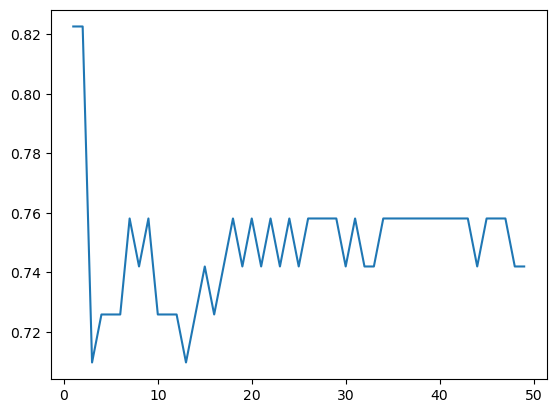

In [72]:
# Let us plot the graph with different n_neighbors values to see the performance changes with changing n_neighbors value
scores = []
for k in range(1,50):
    kNNModelPerf = KNeighborsClassifier(n_neighbors=k, weights='distance')
    kNNModelPerf.fit(X_train, Y_train)
    scores.append(kNNModelPerf.score(X_test, Y_test))

plt.plot(range(1,50), scores)

**Looks like performance of the model is above 82% when n_neighbors value is 2, So we will do this test with k=2.**

#### Experiment other parameters change to improve the performance of the model

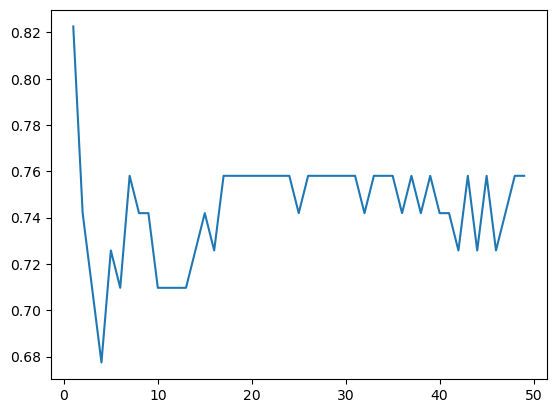

In [73]:
# let us change the the weights parameter to uniform to see if any performance improvement
scoresTest = []
for k in range(1,50):
    kNNModelTest = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    kNNModelTest.fit(X_train, Y_train)
    scoresTest.append(kNNModelTest.score(X_test, Y_test))

plt.plot(range(1,50), scoresTest)

* Similar performance can be seen for different values of n_neighbors even if we changed weights from distance to uniform, so we will keep weights to distance only for future experiments

In [74]:
# define a method for plotting performance graph based on different metric
def kNNPerformancePlot(m):
    scoresTest = []
    for k in range(1,50):
        kNNModelTest = KNeighborsClassifier(n_neighbors=k, weights='distance',metric=m)
        kNNModelTest.fit(X_train, Y_train)
        scoresTest.append(kNNModelTest.score(X_test, Y_test))

    plt.plot(range(1,50), scoresTest)

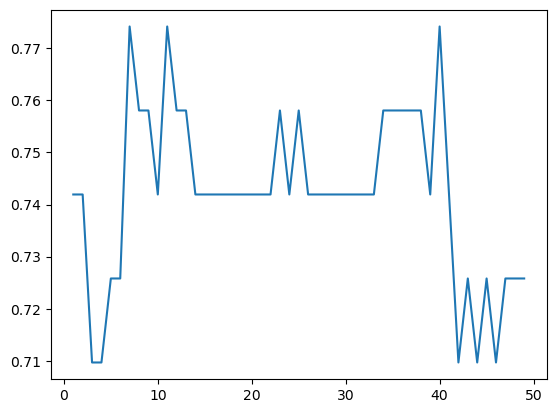

In [75]:
# let us try different available metrics for distance computation to see if any performance improvement
kNNPerformancePlot('manhattan') #manhattan distance computation method

* Performance not as good as the default one i.e euclidean 82%, For this graph max performance score is 80% for different values of n_neighbors

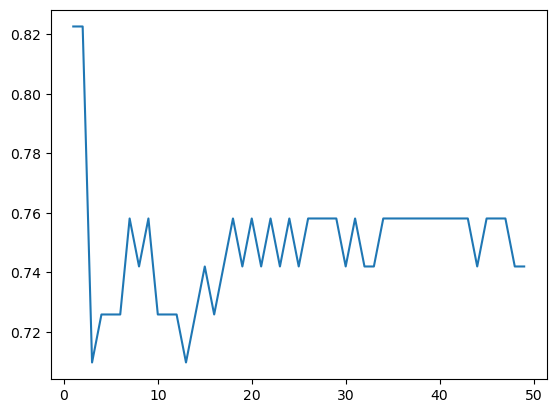

In [76]:
kNNPerformancePlot('minkowski') #minkowski distance computation method

* Performance is same as first plot

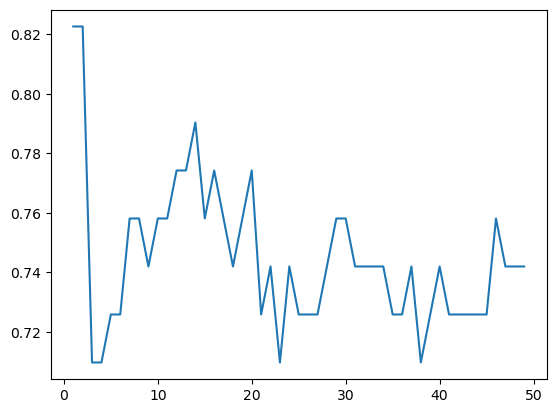

In [77]:
kNNPerformancePlot('chebyshev') #chebyshev distance computation method

* Performance is same as first plot

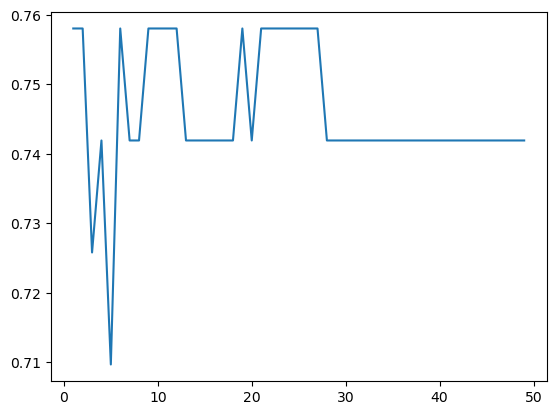

In [78]:
kNNPerformancePlot('cosine') #cosine metric for distance computation

* Performance not better than 82% for any value, so will ignore this as well. 

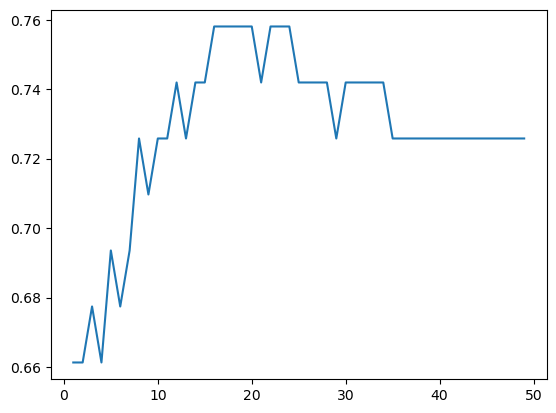

In [79]:
kNNPerformancePlot('correlation') 

* Performance not better than 82% for any value, so will ignore this as well. 
#### So based on above experiments changing different parameters, we found that 82% is the max performance with weights='distance' and n_neighbors=2 and metric default which is euclidean, so we will go ahead with this model

##### B. Clearly showcase improvement in performance achieved. [1 Marks]

In [80]:
kNNModelPerf = KNeighborsClassifier(n_neighbors = 2, weights='distance') #build the model
kNNModelPerf.fit(X_train, Y_train) #train the model
kNNModelPerf.score(X_train, Y_train) # score of model on training data

1.0

In [81]:
# Predict the Class on X_test data
predicted_class_perf = kNNModelPerf.predict(X_test)
# check the performance on test data i.e test score
kNNModelPerf.score(X_test, Y_test)

0.8225806451612904

**We see the model performance is improved by almost 10%.**    
*  when n_neighbors = 5, Performance of model was 72.5% on test data  
*  Now when n_neighbors = 2, Performance of model is 82.25% on test data, which is better

<Axes: >

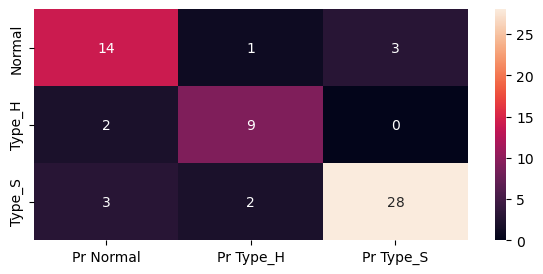

In [82]:
# draw confustion matrix and plot that through heatmap
cm = metrics.confusion_matrix(Y_test, predicted_class_perf, labels=lab)
cmdf = pd.DataFrame(cm, index=[l for l in lab], columns=[l for l in plab])
plt.figure(figsize=(7,3))
sns.heatmap(cmdf, annot=True) 

#### Before Matrix

In [83]:
#print again all the performance matrix before performance improvment for comparision puppose
print(metrics.classification_report(Y_test, predicted_class, labels=lab))

              precision    recall  f1-score   support

      Normal       0.57      0.67      0.62        18
      Type_H       0.64      0.64      0.64        11
      Type_S       0.87      0.79      0.83        33

    accuracy                           0.73        62
   macro avg       0.69      0.70      0.69        62
weighted avg       0.74      0.73      0.73        62



#### After Matrix

In [84]:
#print all the performance matrix after performance improvement
print(metrics.classification_report(Y_test, predicted_class_perf, labels=lab))

              precision    recall  f1-score   support

      Normal       0.74      0.78      0.76        18
      Type_H       0.75      0.82      0.78        11
      Type_S       0.90      0.85      0.88        33

    accuracy                           0.82        62
   macro avg       0.80      0.81      0.80        62
weighted avg       0.83      0.82      0.82        62



**We can clearly see the comparision of performance improvement for before and after classification report as shown above**    
#### Let us differentiate both the classification report values and prepare a table to show how much % is the increase in improvement

**<center> Performance Improvement difference in Percentage: </center>**

|          | precision | recall | f1-score |
|----------|----------|----------|----------|
| Normal   | 17%      | 11%      | 14%      |
| Type_H   | 11%      | 18%      | 14%      |
| Type_S   | 3%       | 6%       | 5%       |
|          |          |          |          |
| Accuracy |          |          | 9%       |
| macro avg| 11%      | 11%      | 11%      |
|weight.avg| 9%       | 9%       | 9%       |

##### C. Clearly state which parameters contributed most to improve model performance. [1 Marks]

* We tried changing multiple parameters like n_neighbors value from 1 to 50, different weights like uniform, distance and different distance computation methods like euclidean, manhattan, minkowski, chebyshev, cosine, correlation etc.
* We saw changing n_neighbours value to from 5 to 2, weights='distance' and metric default i.e euclidean while instantiating kNNClassifer model changed the performance of model by almost 10%

### Part B - 30 Marks

***• DOMAIN:*** Banking, Marketing  
***• CONTEXT:*** A bank X is on a massive digital transformation for all its departments. Bank has a growing customer base where majority of them are 
liability customers (depositors) vs borrowers (asset customers). The bank is interested in expanding the borrowers base rapidly to bring in more 
business via loan interests. A campaign that the bank ran in last quarter showed an average single digit conversion rate. Digital transformation 
being the core strength of the business strategy, marketing department wants to devise effective campaigns with better target marketing to 
increase the conversion ratio to double digit with same budget as per last campaign.   
***• DATA DICTIONARY:***  
***1. ID:*** Customer ID  
***2. Age:*** Customer’s approximate age.  
***3. CustomerSince:*** Customer of the bank since. [unit is masked]  
***4. HighestSpend:*** Customer’s highest spend so far in one transaction. [unit is masked]  
***5. ZipCode:*** Customer’s zip code.  
***6. HiddenScore:*** A score associated to the customer which is masked by the bank as an IP.  
***7. MonthlyAverageSpend:*** Customer’s monthly average spend so far. [unit is masked]  
***8. Level:*** A level associated to the customer which is masked by the bank as an IP.  
***9. Mortgage:*** Customer’s mortgage. [unit is masked]  
***10. Security:*** Customer’s security asset with the bank. [unit is masked]  
***11. FixedDepositAccount:*** Customer’s fixed deposit account with the bank. [unit is masked]  
***12. InternetBanking:*** if the customer uses internet banking.  
***13. CreditCard:*** if the customer uses bank’s credit card.  
***14. LoanOnCard:*** if the customer has a loan on credit card.  
***• PROJECT OBJECTIVE:*** Build a Machine Learning model to perform focused marketing by predicting the potential customers who will convert 
using the historical dataset.  
***• STEPS AND TASK [30 Marks]:***  
***1. Data Understanding and Preparation: [5 Marks]***  
##### A. Read both the Datasets ‘Data1’ and ‘Data 2’ as DataFrame and store them into two separate variables. [1 Marks]  


In [85]:
# Load the datasets 
data1 = pd.read_csv('Data1.csv')
data2 = pd.read_csv('Data2.csv')

In [86]:
# Read the dataframe to verify the data is loaded correctly
data1.head()

,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level
0,1,25,1,49,91107,4,1.6,1
1,2,45,19,34,90089,3,1.5,1
2,3,39,15,11,94720,1,1.0,1
3,4,35,9,100,94112,1,2.7,2
4,5,35,8,45,91330,4,1.0,2


In [87]:
# Read the dataframe to verify the data is loaded correctly
data2.head()

,ID,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
0,1,0,1,0,0,0,NaN
1,2,0,1,0,0,0,NaN
2,3,0,0,0,0,0,NaN
3,4,0,0,0,0,0,NaN
4,5,0,0,0,0,1,NaN


##### B. Print shape and Column Names and DataTypes of both the Dataframes. [1 Marks]

In [88]:
print("Shape of data1:", data1.shape)
print("Columns of data1:", list(data1.columns))
print("Datatypes of data1:\n" + str(data1.dtypes))

Shape of data1: (5000, 8)
Columns of data1: ['ID', 'Age', 'CustomerSince', 'HighestSpend', 'ZipCode', 'HiddenScore', 'MonthlyAverageSpend', 'Level']
Datatypes of data1:
ID                       int64
Age                      int64
CustomerSince            int64
HighestSpend             int64
ZipCode                  int64
HiddenScore              int64
MonthlyAverageSpend    float64
Level                    int64
dtype: object


In [89]:
print("Shape of data2:", data2.shape)
print("Columns of data2:", list(data2.columns))
print("Datatypes of data2:\n" + str(data2.dtypes))

Shape of data2: (5000, 7)
Columns of data2: ['ID', 'Mortgage', 'Security', 'FixedDepositAccount', 'InternetBanking', 'CreditCard', 'LoanOnCard']
Datatypes of data2:
ID                       int64
Mortgage                 int64
Security                 int64
FixedDepositAccount      int64
InternetBanking          int64
CreditCard               int64
LoanOnCard             float64
dtype: object


* Dataframe data1 has 5000 rows and 8 columns
* Dataframe data2 has 5000 rows and 7 columns
* Both the dataframes have all the columns numerical. 
* Just one column MonthlyAverageSpend is float 64 and rest all is int64 in dataframe data1
* Just one column LoanOnCard is float64 and rest all are int64 in dataframe data2

##### C. Merge both the Dataframes on ‘ID’ feature to form a single DataFrame [2 Marks]

In [90]:
#merge the dataframes data1 and data2
merged = pd.merge(data1, data2, on="ID", how="inner")

In [91]:
#view the merged dataframes based on ID
merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   5000 non-null   int64  
 1   Age                  5000 non-null   int64  
 2   CustomerSince        5000 non-null   int64  
 3   HighestSpend         5000 non-null   int64  
 4   ZipCode              5000 non-null   int64  
 5   HiddenScore          5000 non-null   int64  
 6   MonthlyAverageSpend  5000 non-null   float64
 7   Level                5000 non-null   int64  
 8   Mortgage             5000 non-null   int64  
 9   Security             5000 non-null   int64  
 10  FixedDepositAccount  5000 non-null   int64  
 11  InternetBanking      5000 non-null   int64  
 12  CreditCard           5000 non-null   int64  
 13  LoanOnCard           4980 non-null   float64
dtypes: float64(2), int64(12)
memory usage: 585.9 KB


#### Observations:
* We can see dataframes data1 and data2 are merged based on ID creating a total of 14 columns i.e 8 from data1, 7 from data2 and minus 1 for ID from data2 
* Rows count will remain same i.e 5000
* Just LoanOnCard has 20 null values, rest all are not null

##### D. Change Datatype of below features to ‘Object’ [1 Marks]
***‘CreditCard’, ‘InternetBanking’, ‘FixedDepositAccount’, ‘Security’, ‘Level’, ‘HiddenScore’.***
* <i> [Reason behind performing this operation:- Values in these features are binary i.e. 1/0. But DataType is ‘int’/’float’ which is not expected.]</i>

In [92]:
# Change the datatype of each column in the list to object type based on below loop
for col in ['CreditCard', 'InternetBanking', 'FixedDepositAccount', 'Security', 'Level', 'HiddenScore']:
    merged[col] = merged[col].astype(object)

In [93]:
#verify the changed datatypes
merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   5000 non-null   int64  
 1   Age                  5000 non-null   int64  
 2   CustomerSince        5000 non-null   int64  
 3   HighestSpend         5000 non-null   int64  
 4   ZipCode              5000 non-null   int64  
 5   HiddenScore          5000 non-null   object 
 6   MonthlyAverageSpend  5000 non-null   float64
 7   Level                5000 non-null   object 
 8   Mortgage             5000 non-null   int64  
 9   Security             5000 non-null   object 
 10  FixedDepositAccount  5000 non-null   object 
 11  InternetBanking      5000 non-null   object 
 12  CreditCard           5000 non-null   object 
 13  LoanOnCard           4980 non-null   float64
dtypes: float64(2), int64(6), object(6)
memory usage: 585.9+ KB


##### 2. Data Exploration and Analysis: [5 Marks]
##### A. Visualize distribution of Target variable ‘LoanOnCard’ and clearly share insights. [2 Marks]

<Axes: xlabel='LoanOnCard', ylabel='count'>

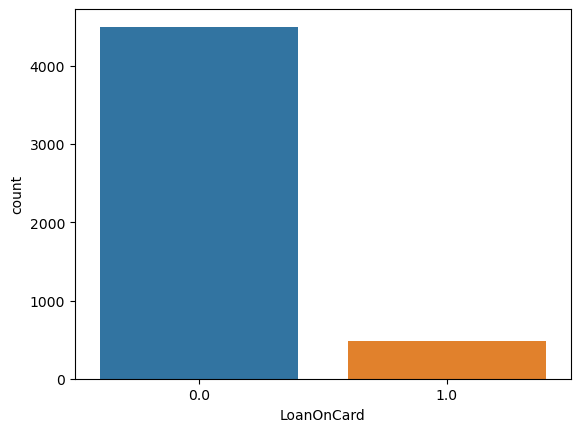

In [94]:
sns.countplot(merged, x='LoanOnCard')

In [95]:
merged['LoanOnCard'].value_counts()

0.0    4500
1.0     480
Name: LoanOnCard, dtype: int64

In [96]:
merged['LoanOnCard'].isnull().sum()

20

**Insights:**
* Target Variable LoanOnCard has 2 not null values 0.0 and 1.0
* It has majority 0.0 values with total count 4500, Meaning Majority people don't have Loan on card
* It has 1.0 value count 480, Meaning only 480 people have loan on card
* It has 20 null values as well.
* We can convert its datatype from float to int values i.e 0 & 1 as this column has binary value. However this is not required to do so. Hence we leave it ias it
* LoanOnCard is having imbalanced distribution. Majority has 0.0 and very few has 1.0

##### B. Check the percentage of missing values and impute if required. [1 Marks]

In [97]:
merged.isnull().sum()

ID                      0
Age                     0
CustomerSince           0
HighestSpend            0
ZipCode                 0
HiddenScore             0
MonthlyAverageSpend     0
Level                   0
Mortgage                0
Security                0
FixedDepositAccount     0
InternetBanking         0
CreditCard              0
LoanOnCard             20
dtype: int64

* We can see only LoanOnCard column has 20 missing values

In [98]:
missing_percentage = (merged['LoanOnCard'].isnull().sum()*100)/len(merged['LoanOnCard'])
print("Percentage of missing values on LoanOnCard column: %0.2f%%" % missing_percentage)

Percentage of missing values on LoanOnCard column: 0.40%


In [99]:
# Let us impute this missing 0.4% value with mode
mode = merged['LoanOnCard'].mode()[0] #find mode
mode

0.0

In [100]:
# impute this missing 0.4% value with mode
merged['LoanOnCard'] = merged['LoanOnCard'].fillna(mode) 

In [101]:
merged['LoanOnCard'].isnull().sum()

0

In [102]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   5000 non-null   int64  
 1   Age                  5000 non-null   int64  
 2   CustomerSince        5000 non-null   int64  
 3   HighestSpend         5000 non-null   int64  
 4   ZipCode              5000 non-null   int64  
 5   HiddenScore          5000 non-null   object 
 6   MonthlyAverageSpend  5000 non-null   float64
 7   Level                5000 non-null   object 
 8   Mortgage             5000 non-null   int64  
 9   Security             5000 non-null   object 
 10  FixedDepositAccount  5000 non-null   object 
 11  InternetBanking      5000 non-null   object 
 12  CreditCard           5000 non-null   object 
 13  LoanOnCard           5000 non-null   float64
dtypes: float64(2), int64(6), object(6)
memory usage: 585.9+ KB


* we have imputed null values with mode value i.e 0.0 in this case
* we don't have any null value now in this dataframe

##### C. Check for unexpected values in each categorical variable and impute with best suitable value. [2 Marks]
<i>[Unexpected values means if all values in a feature are 0/1 then ‘?’, ‘a’, 1.5 are unexpected values which needs treatment ]</i>

In [103]:
merged.head()

,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
0,1,25,1,49,91107,4,1.6,1,0,1,0,0,0,0.0
1,2,45,19,34,90089,3,1.5,1,0,1,0,0,0,0.0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0.0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0.0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,1,0.0


In [104]:
# If we see the datatype in merged.info() result, there are 6 columns of object type i.e. categorical
cols_to_scan = ['CreditCard', 'InternetBanking', 'FixedDepositAccount', 'Security', 'Level', 'HiddenScore']
for col in cols_to_scan:
    print(merged[col].value_counts())

0    3530
1    1470
Name: CreditCard, dtype: int64
1    2984
0    2016
Name: InternetBanking, dtype: int64
0    4698
1     302
Name: FixedDepositAccount, dtype: int64
0    4478
1     522
Name: Security, dtype: int64
1    2096
3    1501
2    1403
Name: Level, dtype: int64
1    1472
2    1296
4    1222
3    1010
Name: HiddenScore, dtype: int64


#### Insights:
* Data is very clean in all these categorical columns
* For Credit Card, InternetBanking, FixedDepositAccount and Security, we just have 0 & 1 values. No unexpected values can be seen
* For Level, we have 1, 2, 3 values. No unexpected values can be seen
* For HiddenScore, we have 1, 2, 3, 4 values No unexpected values can be seen
* So, No imputation is required here.

##### 3. Data Preparation and model building: [10 Marks]
##### A. Split data into X and Y. [1 Marks]
<i> [Recommended to drop ID & ZipCode. LoanOnCard is target Variable]</i>

In [105]:
#Let us check if there is any duplicates.
merged.duplicated().sum() 

0

In [106]:
#Let us copy the merged dataframe to a new dataframe merged_copy to perform delete column operations, 
#just to keep merged dataframe untouched.
merged_copy = merged.copy(deep=True)
# ID, Zip code is not required, so we will drop these columns
merged_copy.drop(['ID','ZipCode'], axis=1, inplace=True)

In [107]:
merged_copy.columns

Index(['Age', 'CustomerSince', 'HighestSpend', 'HiddenScore',
       'MonthlyAverageSpend', 'Level', 'Mortgage', 'Security',
       'FixedDepositAccount', 'InternetBanking', 'CreditCard', 'LoanOnCard'],
      dtype='object')

* We can see those columns are dropped from merged dataframe

In [108]:
# Loan on Card is the target variable. So we will exclude that from X and we will keep LoanOnCard in Y
X = merged_copy.drop('LoanOnCard', axis=1)
Y = merged_copy['LoanOnCard']

In [109]:
#Let us just read the data to see if it is loaded correctly in X
X

,Age,CustomerSince,HighestSpend,HiddenScore,MonthlyAverageSpend,Level,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard
0,25,1,49,4,1.6,1,0,1,0,0,0
1,45,19,34,3,1.5,1,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,1,1.9,3,0,0,0,1,0
4996,30,4,15,4,0.4,1,85,0,0,1,0
4997,63,39,24,2,0.3,3,0,0,0,0,0
4998,65,40,49,3,0.5,2,0,0,0,1,0


In [110]:
#Let us just read the data to see if it is loaded correctly in Y
Y

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
4995    0.0
4996    0.0
4997    0.0
4998    0.0
4999    0.0
Name: LoanOnCard, Length: 5000, dtype: float64

##### B. Split data into train and test. Keep 25% data reserved for testing. [1 Marks]

In [111]:
#split the data X and Y into 75:25 ratio for training and testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=1)

In [112]:
#Let us verify the data size of X_train, Y_train, X_test, Y_test if it is split in 75:25 ratio
print("X_train size(in percentage):",X_train.shape[0]*100/X.shape[0])
print("Y_train size(in percentage):",Y_train.shape[0]*100/Y.shape[0])

print("X_test size(in percentage):",X_test.shape[0]*100/X.shape[0])
print("Y_test size(in percentage):",Y_test.shape[0]*100/Y.shape[0])

X_train size(in percentage): 75.0
Y_train size(in percentage): 75.0
X_test size(in percentage): 25.0
Y_test size(in percentage): 25.0


In [113]:
#Let us check the data split on target variable
print("Original LoanOnCard 1.0 Values    : {0} ({1:0.2f}%)".format(len(merged_copy.loc[merged_copy['LoanOnCard'] == 1.0]), (len(merged_copy.loc[merged_copy['LoanOnCard'] == 1.0])/len(merged_copy.index)) * 100))
print("Original LoanOnCard 0.0 Values   : {0} ({1:0.2f}%)".format(len(merged_copy.loc[merged_copy['LoanOnCard'] == 0.0]), (len(merged_copy.loc[merged_copy['LoanOnCard'] == 0.0])/len(merged_copy.index)) * 100))
print("")
print("Training LoanOnCard 1.0 Values    : {0} ({1:0.2f}%)".format(len(Y_train.loc[Y_train[:] == 1.0]), (len(Y_train.loc[Y_train[:] == 1.0])/len(Y_train.index)) * 100))
print("Training LoanOnCard 0.0 Values   : {0} ({1:0.2f}%)".format(len(Y_train.loc[Y_train[:] == 0.0]), (len(Y_train.loc[Y_train[:] == 0.0])/len(Y_train.index)) * 100))
print("")
print("Test LoanOnCard 1.0 Values        : {0} ({1:0.2f}%)".format(len(Y_test.loc[Y_test[:] == 1.0]), (len(Y_test.loc[Y_test[:] == 1.0])/len(Y_test.index)) * 100))
print("Test LoanOnCard 0.0 Values       : {0} ({1:0.2f}%)".format(len(Y_test.loc[Y_test[:] == 0.0]), (len(Y_test.loc[Y_test[:] == 0.0])/len(Y_test.index)) * 100))
print("")

Original LoanOnCard 1.0 Values    : 480 (9.60%)
Original LoanOnCard 0.0 Values   : 4520 (90.40%)

Training LoanOnCard 1.0 Values    : 351 (9.36%)
Training LoanOnCard 0.0 Values   : 3399 (90.64%)

Test LoanOnCard 1.0 Values        : 129 (10.32%)
Test LoanOnCard 0.0 Values       : 1121 (89.68%)



* LoanOnCard Data is split in train and test data in expected ratio, similar ratio as in original dataset LoanOnCard i.e 10:90 for 1.0 and 0.0 values respectively
* This is quite imbalanced target variable distribution

##### C. Train a Supervised Learning Classification base model - Logistic Regression. [2 Marks]

In [114]:
from sklearn.linear_model import LogisticRegression #import required library for logisticRegression
LogisticRegModel = LogisticRegression(solver='liblinear') #instantiate the LogisticRegression model
LogisticRegModel.fit(X_train, Y_train) #Train the model

LogisticRegression(solver='liblinear')

In [115]:
Y_predict = LogisticRegModel.predict(X_test) #Test the model by predicting

##### D. Print evaluation metrics for the model and clearly share insights. [1 Marks]

**Let us print the score on training and testing data**

In [116]:
LogisticRegModel.score(X_train, Y_train) #Score on training data

0.9517333333333333

In [117]:
LogisticRegModel.score(X_test, Y_test) #Score on testing data

0.9448

**Insights:**
* Very good score of 95% on training data
* Very good score of 94.5% on testing data.   
* **It tells it is a good model as the score is very good on both training and testing data.but in case of imbalanced datasets(which is our case as we have 10:90 ratio for 1.0 and 0.0 respectively), this score can be misleading. if one class dominates the dataset, a model can say high accuracy by simply predicting majority class. So Let us consider some other performance evaluation metrices**

In [118]:
coef_df = pd.DataFrame(LogisticRegModel.coef_)
coef_df

,0,1,2,3,4,5,6,7,8,9,10
0,-0.408749,0.407679,0.050567,0.631663,0.140505,1.724943,0.000911,-0.897426,3.15029,-0.589192,-0.914943


In [119]:
coef_df['intercept']=LogisticRegModel.intercept_
coef_df

,0,1,2,3,4,5,6,7,8,9,10,intercept
0,-0.408749,0.407679,0.050567,0.631663,0.140505,1.724943,0.000911,-0.897426,3.15029,-0.589192,-0.914943,-2.501368


In [120]:
#Performance Evaluation Metrices
print("Accuracy Score:", metrics.accuracy_score(Y_test, Y_predict))
print("Precision Score:", metrics.precision_score(Y_test, Y_predict))
print("Recall Score:",metrics.recall_score(Y_test, Y_predict))
print("F1 Score:",metrics.f1_score(Y_test, Y_predict))

Accuracy Score: 0.9448
Precision Score: 0.8260869565217391
Recall Score: 0.5891472868217055
F1 Score: 0.6877828054298643


* Overall Precision, Recall and F1 Score are not good. we would need to work on performance improvement

<Axes: >

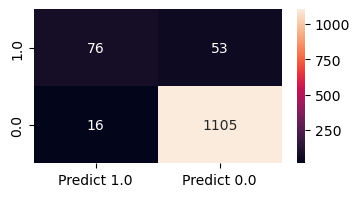

In [121]:
cm=metrics.confusion_matrix(Y_test, Y_predict, labels=[1.0, 0.0])

df_cm = pd.DataFrame(cm, index = [i for i in ["1.0","0.0"]],
                  columns = [i for i in ["Predict 1.0","Predict 0.0"]])
plt.figure(figsize=(4,2))
sns.heatmap(df_cm, annot=True, fmt="g")

* True Positive: we correctly predicted that 76 have 1.0 i.e they have LoanOnCard
* False Positive: We incorrectly predicted that 16 have 1.0 i.e have LoanOnCard, they actually have 0.0 i.e No Loan on card
* True Negative: We correct predicted that 115 have 0.0 i.e they don't have LoanOnCard
* False Negative: We incorrectly predicted that 53 have 0.0 i.e no loan on card, but they actually have 1.0 i.e loan on card

In [122]:
#Classwise evaluation matrices
print(metrics.classification_report(Y_test, Y_predict))

              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97      1121
         1.0       0.83      0.59      0.69       129

    accuracy                           0.94      1250
   macro avg       0.89      0.79      0.83      1250
weighted avg       0.94      0.94      0.94      1250



* For 0.0 we have got good precision, recall and f1 score values but for 1.0 the scores are not good.
* Recall of minority class i.e 1.0 is very less. it means it is biased towards majority class.

##### E. Balance the data using the right balancing technique. [2 Marks]
→ Target balancing can be done by upsampling the minority class or downsampling the majority class
or by using SMOTE as per target distribution. You can research a bit and do this task.

<Axes: xlabel='LoanOnCard', ylabel='count'>

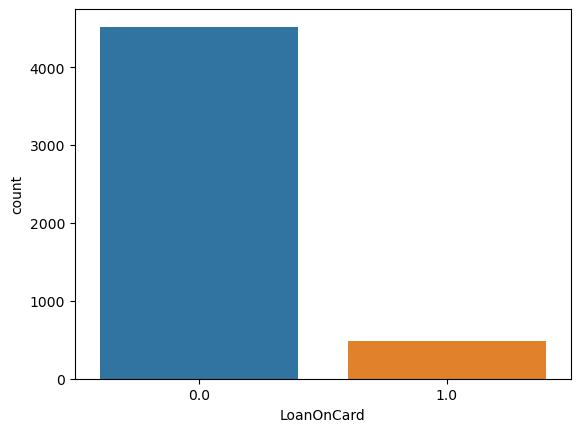

In [123]:
sns.countplot(merged_copy, x='LoanOnCard')

* We can see the distribution of 0.0 is quite high and distribution of 1.0 is low compared to 0.0, which is imbalanced
* 0.0 is the majority class
* 1.0 is minority class here.

**We will use one of the Oversampling methods called SMOTE(Synthetic Minority Over-sampling Technique) to generate the synthetic samples for minority class and then will see the result**

In [125]:
# Already installed this library
# !pip install imblearn
# !pip install --upgrade scikit-learn

In [834]:
#pip install --upgrade imbalanced-learn  #commented out these after installation so that it does not do it again

  Obtaining dependency information for imbalanced-learn from https://files.pythonhosted.org/packages/a3/9e/fbe60a768502af54563dcb59ca7856f5a8833b3ad5ada658922e1ab09b7f/imbalanced_learn-0.11.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/235.6 kB ? eta -:--:--
   ---------- ----------------------------- 61.4/235.6 kB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 235.6/235.6 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.10.1
    Uninstalling imbalanced-learn-0.10.1:
      Successfully uninstalled imbalanced-learn-0.10.1
Note: you may need to restart the kernel to use updated packages.


In [836]:
# pip show scikit-learn  #commented out these after installation so that it does not do it again

Name: scikit-learn
Version: 1.3.2
Summary: A set of python modules for machine learning and data mining
Home-page: http://scikit-learn.org
Author: 
Author-email: 
License: new BSD
Location: C:\Users\Shree\anaconda3\Lib\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: daal4py, imbalanced-learn, scikit-learn-intelex
Note: you may need to restart the kernel to use updated packages.


In [165]:
#import the library after restarting the kernel
from imblearn.over_sampling import SMOTE

In [170]:
print("Before oversampling, Size of X_train: {0}".format(X_train.shape))
print("Before oversampling, Size of Y_train: {0}\n".format(Y_train.shape))

print("Before oversampling, Training LoanOnCard 1.0 Values: {0} ({1:0.2f}%)".format(len(Y_train.loc[Y_train[:] == 1.0]), (len(Y_train.loc[Y_train[:] == 1.0])/len(Y_train.index)) * 100))
print("Before oversampling, Training LoanOnCard 0.0 Values: {0} ({1:0.2f}%)".format(len(Y_train.loc[Y_train[:] == 0.0]), (len(Y_train.loc[Y_train[:] == 0.0])/len(Y_train.index)) * 100))


Before oversampling, Size of X_train: (3750, 11)
Before oversampling, Size of Y_train: (3750,)

Before oversampling, Training LoanOnCard 1.0 Values: 351 (9.36%)
Before oversampling, Training LoanOnCard 0.0 Values: 3399 (90.64%)


In [167]:
#apply smote algorightm to resample
sm = SMOTE(random_state=42)
X_train_res, Y_train_res = sm.fit_resample(X_train, Y_train)

In [168]:
print("After oversampling, Size of X_train_res: {0}".format(X_train_res.shape[0]))
print("After oversampling, Size of Y_train_res: {0}\n".format(Y_train_res.shape[0]))

print("After oversampling, Training LoanOnCard 1.0 Values: {0} ({1:0.2f}%)".format(len(Y_train_res.loc[Y_train_res[:] == 1.0]), (len(Y_train_res.loc[Y_train_res[:] == 1.0])/len(Y_train_res.index)) * 100))
print("After oversampling, Training LoanOnCard 0.0 Values: {0} ({1:0.2f}%)".format(len(Y_train_res.loc[Y_train_res[:] == 0.0]), (len(Y_train_res.loc[Y_train_res[:] == 0.0])/len(Y_train_res.index)) * 100))


After oversampling, Size of X_train_res: 6798
After oversampling, Size of Y_train_res: 6798

After oversampling, Training LoanOnCard 1.0 Values: 3399 (50.00%)
After oversampling, Training LoanOnCard 0.0 Values: 3399 (50.00%)


In [171]:
Y_train_res.value_counts()

0.0    3399
1.0    3399
Name: LoanOnCard, dtype: int64

**We can see we have balanced minority class 1.0 from 9.36% to 50% using SMOTE method of oversampling, Now we have 0.0 and 1.0 both 50% and will perfrom training and testing on this to see the result** 

##### F. Again train the same previous model on balanced data. [1 Marks]

In [173]:
LRModel = LogisticRegression(solver='liblinear') #instantiate the LogisticRegression model
LRModel.fit(X_train_res, Y_train_res) #Train the model on resampled data

LogisticRegression(solver='liblinear')

In [174]:
Y_predict_res = LRModel.predict(X_test) #Test the model by predicting

##### G. Print evaluation metrics and clearly share differences observed. [2 Marks]

Let us print the performance scores on traning and testing data

In [175]:
LRModel.score(X_train_res, Y_train_res)

0.9111503383348043

In [176]:
LRModel.score(X_test, Y_test)

0.9008

* Score in good on resampled training and testing data. it can be a good model. Let us check some other metrices to be sure.

In [177]:
#Performance Evaluation Metrices
print("Accuracy Score:", metrics.accuracy_score(Y_test, Y_predict_res))
print("Precision Score:", metrics.precision_score(Y_test, Y_predict_res))
print("Recall Score:",metrics.recall_score(Y_test, Y_predict_res))
print("F1 Score:",metrics.f1_score(Y_test, Y_predict_res))

Accuracy Score: 0.9008
Precision Score: 0.511520737327189
Recall Score: 0.8604651162790697
F1 Score: 0.6416184971098267


* We can see the Recall is improved from 58 to 86% which is good.
* Since this is banking related data, High recall is important because it measures the ability of the model to correctly identify individuals who are likely to default. It helps in minimizing the loan defaults to reduce the financial losses

<Axes: >

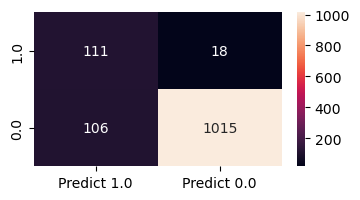

In [179]:
cm=metrics.confusion_matrix(Y_test, Y_predict_res, labels=[1.0, 0.0])

df_cm = pd.DataFrame(cm, index = [i for i in ["1.0","0.0"]],
                  columns = [i for i in ["Predict 1.0","Predict 0.0"]])
plt.figure(figsize=(4,2))
sns.heatmap(df_cm, annot=True, fmt="g")

* True Positive: we correctly predicted that 111 have 1.0 i.e they have LoanOnCard
* False Positive: We incorrectly predicted that 106 have 1.0 i.e have LoanOnCard, they actually have 0.0 i.e No Loan on card
* True Negative: We correct predicted that 1015 have 0.0 i.e they don't have LoanOnCard
* False Negative: We incorrectly predicted that 18 have 0.0 i.e no loan on card, but they actually have 1.0 i.e loan on card

In [182]:
#Classwise evaluation matrices
print(metrics.classification_report(Y_test, Y_predict_res))

              precision    recall  f1-score   support

         0.0       0.98      0.91      0.94      1121
         1.0       0.51      0.86      0.64       129

    accuracy                           0.90      1250
   macro avg       0.75      0.88      0.79      1250
weighted avg       0.93      0.90      0.91      1250



We can see the improvement in scores:
* Precision for 0.0 is increased from 0.95 to 0.98, whereas for 1.0, it is decreased from 0.83 to 0.51
* Recall for 0.0 is decreased from 0.99 to 0.91, whereas for 1.0, it is increased from 0.59 to 0.86
* F1-score for 0.0 is decreased from 0.97 to 0.94 and for 1.0 also it is decreased from 0.69 to 0.64
* Though we have a bit score drop at some point and some score up as well but that should be fine, at least it is now not biased while predicting. so it is better.

##### 4. Performance Improvement: [10 Marks]
##### A. Train a base model each for SVM, KNN. [4 Marks] 
##### B. Tune parameters for each of the models wherever required and finalize a model. [3 Marks]
**Note:**: Answers of both questions 4.A & B is together as below
 #### SVM

In [282]:
#### We need to do this on the balanced data i.e X_train_res and Y_train_res
#### SVM
from sklearn import svm
svmModel = svm.SVC(gamma=0.025, C=3) #build the model, here default kernel is rbf
svmModel.fit(X_train_res, Y_train_res) #train the model, X_train_res and Y_train_res is resampled data

SVC(C=3, gamma=0.025)

In [283]:
Y_predict_svm = svmModel.predict(X_test) #predict the model
svmModel.score(X_test, Y_test) #get score of the model

0.924

* 92.4% is the score, which is good but has scope of improvement. 


#### Try different parameters for SVM
**Perform hyperparameter tuning using grid search which automatically perform cross-validation for each combination of hyperparameters and identify the best-performing set.**

In [284]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1]}
grid_search = GridSearchCV(svm.SVC(), param_grid, cv=5)
grid_search.fit(X_train_res, Y_train_res)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1]})

In [285]:
# Get the best parameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Get the best model
best_model = grid_search.best_estimator_
print('Best Model', best_model)

# Get the best cross-validated score
best_score = grid_search.best_score_
print("Best Cross-validated Score:", best_score)

Best Hyperparameters: {'C': 10, 'gamma': 0.01}
Best Model SVC(C=10, gamma=0.01)
Best Cross-validated Score: 0.9724910184824482


* So the best score for svm we are getting at parameters {'C': 10, 'gamma': 0.01}, Let us try to get the score by implenting this model with above hyperparameters

In [300]:
#define function to get scores based on different kernels
def getSVMScores(kernel):
    svmModel = svm.SVC(gamma=0.01, C=10, kernel=kernel)
    svmModel.fit(X_train_res, Y_train_res)
    print("SVM score for kernel {0} : {1}".format(kernel, svmModel.score(X_test, Y_test)))

In [301]:
getSVMScores('linear')

SVM score for kernel linear : 0.8936


In [302]:
getSVMScores('poly')

SVM score for kernel poly : 0.9528


In [303]:
getSVMScores('sigmoid')

SVM score for kernel sigmoid : 0.1032


**Looking at the above scores with different kernels, we find that C=10, gamma=0.01 and kernel='poly' is giving best and highest performance score of 95.28%**

#### KNN

In [203]:
#KNN
kNeighborsModel = KNeighborsClassifier(n_neighbors=5, weights='distance') #build the model
kNeighborsModel.fit(X_train_res, Y_train_res) #train the knn model, X_train_res and Y_train_res is resampled data

KNeighborsClassifier(weights='distance')

In [210]:
Y_predict_knn = kNeighborsModel.predict(X_test) 
print(kNeighborsModel.score(X_train_res, Y_train_res))
print(kNeighborsModel.score(X_test, Y_test))

1.0
0.8504


* 100% score is very good on training data but 
* 85.04% is the score on testing data, which is Ok but it is less than SVM model score

#### Try different parameters for KNN

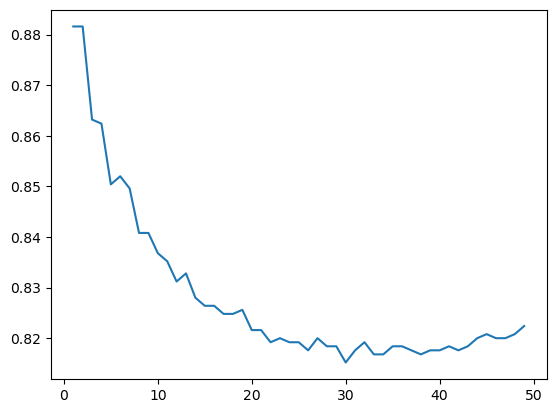

In [212]:
# Let us try different values of K here to see if see performance at different point
kNNScores = []
for k in range(1,50):
    kNeighborsModelTry = KNeighborsClassifier(n_neighbors=k, weights='distance')
    kNeighborsModelTry.fit(X_train_res, Y_train_res)
    Y_predict_knn = kNeighborsModelTry.predict(X_test) 
    kNNScores.append(kNeighborsModelTry.score(X_test, Y_test))
    
plt.plot(range(1,50), kNNScores)

* Looking at the graph it looks like highest score is at k=1 but ideally keeping k=1 is not advisable.
* A small value of k, especially k=1, increases the risk of overfitting. The model may memorize the training set, including noise or outliers, instead of learning the underlying patterns
* We see that with decrement in k value, performance score is also decreasing till the k value 30 and after that there is slight up. So since k value 1 or 2 will be not be good but we can consider k value 3.   
** Here k refers to n_neighbors

In [214]:
kNeighborsModel = KNeighborsClassifier(n_neighbors=3, weights='distance') #build the model
kNeighborsModel.fit(X_train_res, Y_train_res) # train the model
Y_predict_knn = kNeighborsModel.predict(X_test) # predict the model
print(kNeighborsModel.score(X_train_res, Y_train_res)) #get the performance score of the model on training data
print(kNeighborsModel.score(X_test, Y_test))  # get the performance score of the model on testing data

1.0
0.8632


* with k=5, we got 85% score but with k=3 we got 86.32% score, which is better but still is not as good as svm

In [227]:
# defined a method to plot performance graph based on different parameters
def kNNPerfromanceResampledPlot(weights, metric):
    kNNScores = []
    for k in range(1,50):
        kNeighborsModelTry = KNeighborsClassifier(n_neighbors=k, weights=weights) #build the model
        kNeighborsModelTry.fit(X_train_res, Y_train_res) #train the model
        Y_predict_knn = kNeighborsModelTry.predict(X_test)  #predict the model
        kNNScores.append(kNeighborsModelTry.score(X_test, Y_test))  #get the scores   
    plt.plot(range(1,50), kNNScores)  #plot the graph

In [234]:
def kNNPerformanceResampledScore(k, weights, metric):
    kNeighborsModel = KNeighborsClassifier(n_neighbors=k, weights=weights, metric=metric) #build the model
    kNeighborsModel.fit(X_train_res, Y_train_res) # train the model
    Y_predict_knn = kNeighborsModel.predict(X_test) # predict the model
    print("Training score:", kNeighborsModel.score(X_train_res, Y_train_res)) #get the performance score of the model on training data
    print("Testing score:",kNeighborsModel.score(X_test, Y_test))  # get the performance score of the model on testing data

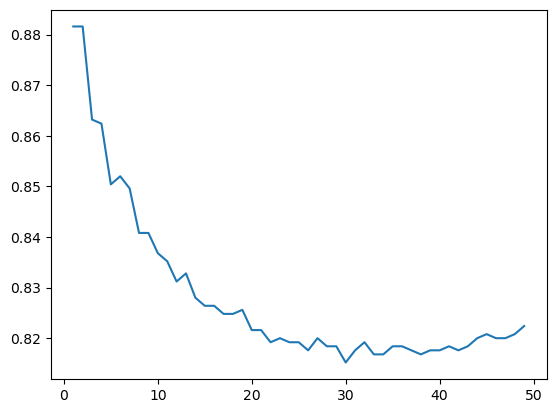

In [235]:
kNNPerfromanceResampledPlot('distance', 'manhattan')

* We see performance score around 89% for k=1 which we should not consider. Let us try to know exact score with k=3.

In [244]:
kNNPerformanceResampledScore(3, 'distance', 'manhattan')

Training score: 1.0
Testing score: 0.8952


* 89.52% is better than previous ones but not better than svm

Training score: 0.960429538099441
Testing score: 0.8696


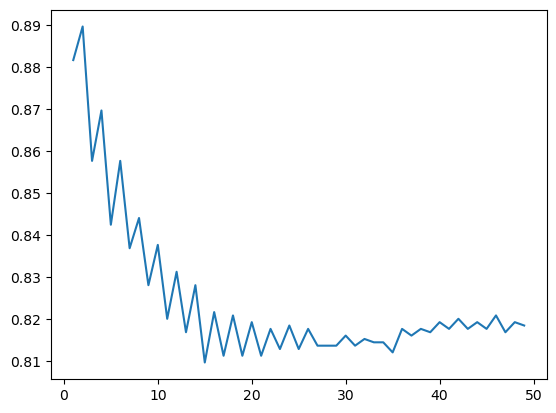

In [245]:
# Try weights uniform and distance computation metric as manhattan
kNNPerfromanceResampledPlot('uniform', 'manhattan')
kNNPerformanceResampledScore(5, 'uniform', 'manhattan') 

* 89.96% is better with k=5 and weights=uniform and metric = manhattan

Training score: 1.0
Testing score: 0.8616


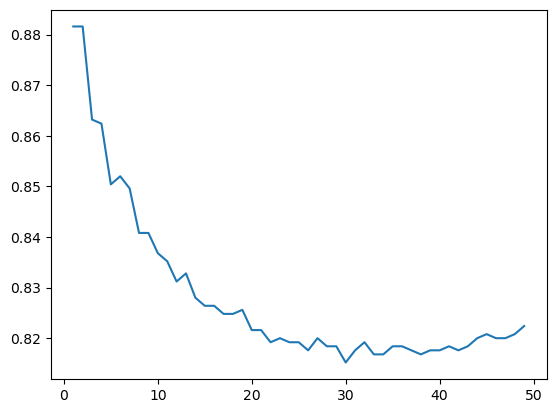

In [252]:
# Try weights distance and distance computation metric as chebyshev
kNNPerfromanceResampledPlot('distance', 'chebyshev')
kNNPerformanceResampledScore(3, 'distance', 'chebyshev') 

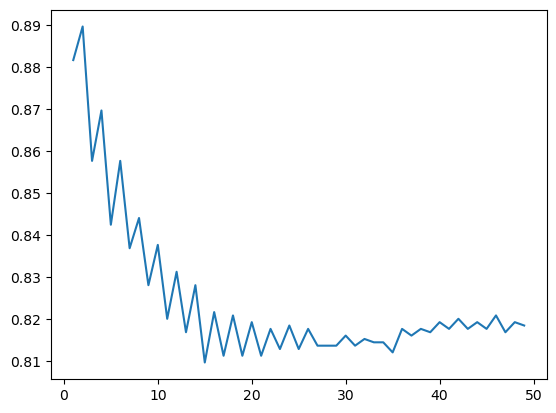

In [262]:
# Try weights uniform and distance computation metric as chebyshev
kNNPerfromanceResampledPlot('uniform', 'chebyshev')

In [261]:
kNNPerformanceResampledScore(3, 'uniform', 'chebyshev') 

Training score: 0.9579288025889967
Testing score: 0.8536


* Not better than other paramters

Training score: 1.0
Testing score: 0.8632


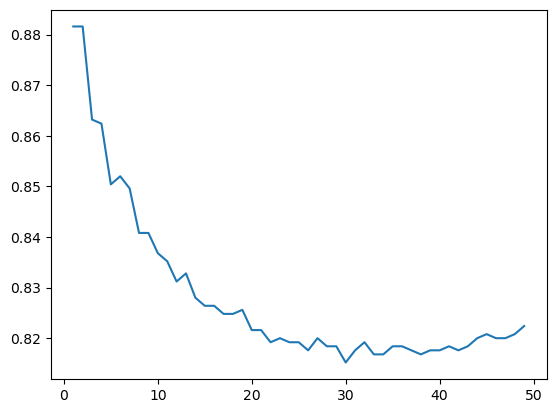

In [265]:
# Try weights distance and distance computation metric as minkowski
kNNPerfromanceResampledPlot('distance', 'minkowski')
kNNPerformanceResampledScore(3, 'distance', 'minkowski') 

Training score: 0.9620476610767873
Testing score: 0.8576


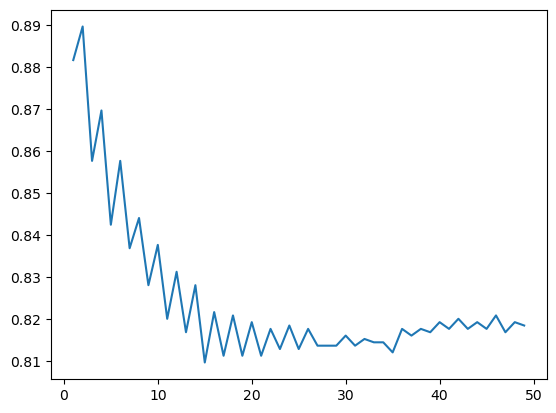

In [266]:
# Try weights uniform and distance computation metric as minkowski
kNNPerfromanceResampledPlot('uniform', 'minkowski')
kNNPerformanceResampledScore(3, 'uniform', 'minkowski') 

**So out of all the KNN paramters tried so far, (n_neightbors=5, weights='uniform', metric='manhattan') has the best score of 89.96% on testing data. but still that is not better than the score 95.28% we got using SVM model**

##### C. Print evaluation metrics for final model. [1 Marks]

* Based on all above experiments with hyperparameters on SVM and KNN models, SVM is the best model in this case with below hyperparameters:

In [306]:
svmModel = svm.SVC(gamma=0.01, C=10, kernel='poly')
svmModel.fit(X_train_res, Y_train_res)
Y_predict_svm = svmModel.predict(X_test)
print("SVM score for kernel {0} : {1}".format(kernel, svmModel.score(X_test, Y_test)))

SVM score for kernel poly : 0.9528


In [307]:
#Performance Evaluation Metrices
print("Accuracy Score:", metrics.accuracy_score(Y_test, Y_predict_svm))
print("Precision Score:", metrics.precision_score(Y_test, Y_predict_svm))
print("Recall Score:",metrics.recall_score(Y_test, Y_predict_svm))
print("F1 Score:",metrics.f1_score(Y_test, Y_predict_svm))

Accuracy Score: 0.9528
Precision Score: 0.7272727272727273
Recall Score: 0.8682170542635659
F1 Score: 0.7915194346289752


* We see very good performance score

<Axes: >

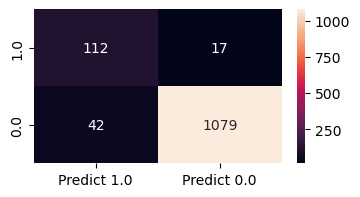

In [309]:
#Confusion matrix
cm=metrics.confusion_matrix(Y_test, Y_predict_svm, labels=[1.0, 0.0])

df_cm = pd.DataFrame(cm, index = [i for i in ["1.0","0.0"]],
                  columns = [i for i in ["Predict 1.0","Predict 0.0"]])
plt.figure(figsize=(4,2))
sns.heatmap(df_cm, annot=True, fmt="g")

* Very less Type 1 and 2 errors which proves it is a good model. 
* True Positive: we correctly predicted that 112 have 1.0 i.e they have LoanOnCard
* False Positive: We incorrectly predicted that 42 have 1.0 i.e have LoanOnCard, they actually have 0.0 i.e No Loan on card
* True Negative: We correctly predicted that 1079 have 0.0 i.e they don't have LoanOnCard
* False Negative: We incorrectly predicted that 17 have 0.0 i.e no loan on card, but they actually have 1.0 i.e loan on card

In [310]:
#Classwise evaluation matrices
print(metrics.classification_report(Y_test, Y_predict_svm))

              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97      1121
         1.0       0.73      0.87      0.79       129

    accuracy                           0.95      1250
   macro avg       0.86      0.92      0.88      1250
weighted avg       0.96      0.95      0.95      1250



* We see good precision, recall, f1-score for each class i.e 0.0 and 1.1 which proves it is a good trained model.

##### D. Share improvement achieved from base model to final model. [2 Marks]

We can clearly see the improvement achieved from the base model. We just saw the scores after improvemnt. 
Let us re-iterate the achievement before base model:  
**On the base model the score was as below:**  
Accuracy Score: 0.9008  
Precision Score: 0.511520737327189  
Recall Score: 0.8604651162790697  
F1 Score: 0.6416184971098267  

**Confusion Matrix:** 
|    | Pr 1.0|Pr 0.0 |
|----|-------|-------|
|1.0 | 111   | 18    |
|0.0 | 106   | 1015  |


**Classification Report:**
|           | precision  |  recall | f1-score  | support   |
|-----------|------------|---------|-----------|-----------|
|        0.0|       0.98 |    0.91 |    0.94   |  1121     |
|        1.0|       0.51 |    0.86 |    0.64   |   129     |
|           |            |         |           |           |
|   accuracy|            |         |   0.90    | 1250      |
|  macro avg|      0.75  |   0.88  |   0.79    | 1250      |
|Weight. avg|      0.93  |   0.90  |   0.91    | 1250      |


**We observe below improvement on base model and current model:**

* Accuracy score increased from 90.08% to 95.28%  
* Precision score increased from 51.15% to 72.72%  
* Recall score increased from 86.04 to 86.82%  
* F1 Score increased from 64.16% to 79.15%     
   
**Classwise increase in percentage of the score in classification report:**  
* Precision score for 1.0 increased from 51% to 73%  
* Recall score for 1.0 incrased from 86% to 87%    
* F1-Score for 1.0 increased from 64% to 79%   
* Macro avg for precision increased from 75% to 86%
* Macro avg for Recall increased from 88% to 92%
* Macro avg for F1-score increased from 79% to 88%
* Weighted avg for Precision increased from 93% to 96%
* Weighted avg for Recall increased from 90% to 95%
* Weighted avg fro F1-score increased from 91% to 95%

**Confusion matrix improvement**
* True positive count increased from 111 to 112
* True Negative count increased from 1015 to 1079
* False positive count decreased from 106 to 42 which is good(error count decreased).
* False Negative count decreased from 18 to 17 which is good(error count increased). 